# TS6 (Estimación Espectral: ECG, PPG y Audio)

Estimación espectral de ECG, PPG y Audio mediante:
- **Periodograma ventaneado** (Hann)
- **Método de Welch**
- **Método de Blackman-Tukey**

Nota: Agrego una señal extra para el analisis. Michael Jackson - Beat It (segundos 30 a 90, debido a que es pesada para el análisis)

In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
import scipy.signal as signal

## Función auxiliar: Blackman-Tukey

Implementación de Mariano Llamedo: https://github.com/marianux/pdstestbench/tree/master

In [2]:
def blackman_tukey(x, M=None):
    x_z = x.shape
    N = np.max(x_z)

    if M is None:
        M = N // 5

    r_len = 2 * M - 1
    xx = x.ravel()[:r_len]
    r = np.correlate(xx, xx, mode='same') / r_len
    Px = np.abs(np.fft.fft(r * signal.windows.blackman(r_len), n=N))
    Px = Px.reshape(x_z)
    return Px


def frecuencias(N, fs):
    """Grilla de frecuencias en Hz que coincide con la FFT de tamaño N."""
    df = fs / N
    ff = np.linspace(0, (N - 1) * df, N)
    return ff, ff <= fs / 2

## Carga de Señales

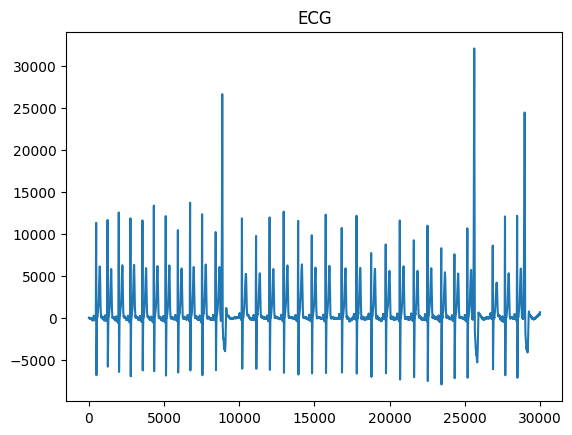

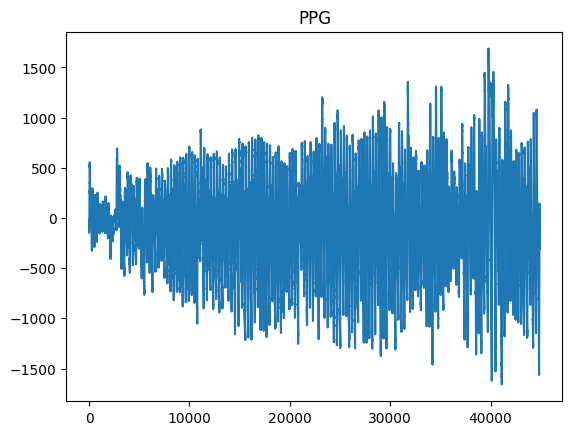

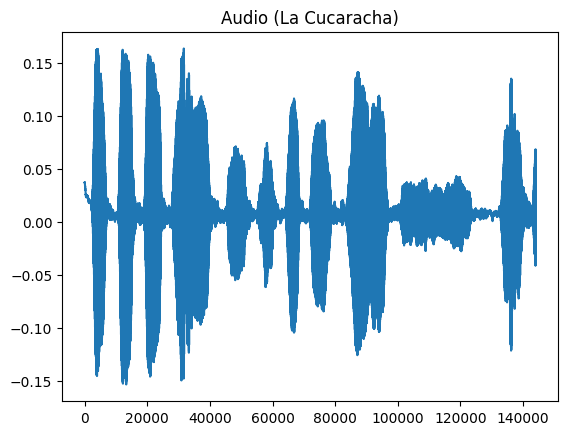

Frecuencia de audio: 48000


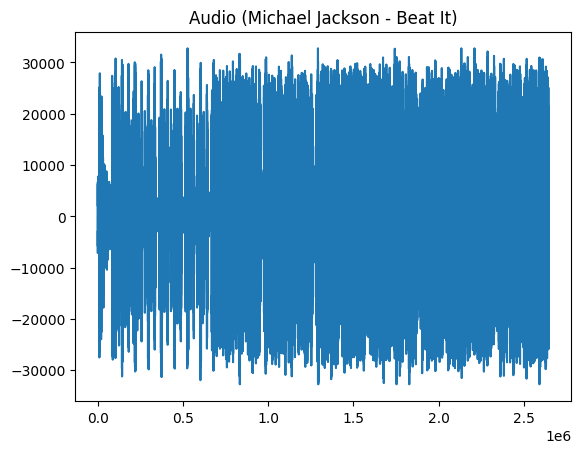

Frecuencia de Michael Jackson: 44100


In [3]:
# Electrocardiograma (.npy)
fs_ecg = 1000
ecg = np.load('signals/ecg_sin_ruido.npy').astype(np.float64).ravel()
plt.figure()
plt.plot(ecg)
plt.title('ECG')
plt.show()

# Pletismografía (.npy)
fs_ppg = 400
ppg = np.load('signals/ppg_sin_ruido.npy').astype(np.float64).ravel()
plt.figure()
plt.plot(ppg)
plt.title('PPG')
plt.show()

# Audio (.wav)
fs_audio, audio = wavfile.read('signals/la cucaracha.wav')
if audio.ndim > 1:
    audio = audio[:, 0]
audio = audio.astype(np.float64)
plt.figure()
plt.plot(audio)
plt.title('Audio (La Cucaracha)')
plt.show()
print("Frecuencia de audio:", fs_audio)

# Michael Jackson (.wav)
fs_mj, mj = wavfile.read('signals/michael_jackson_beat_it.wav')
if mj.ndim > 1:
    mj = mj[:, 0]
mj = mj.astype(np.float64)
mj = mj[int(30 * fs_mj):int(90 * fs_mj)]  # segundos 30 a 90
plt.figure()
plt.plot(mj)
plt.title('Audio (Michael Jackson - Beat It)')
plt.show()
print("Frecuencia de Michael Jackson:", fs_mj)

## Estimación Espectral: Periodograma Ventaneado (Hann)

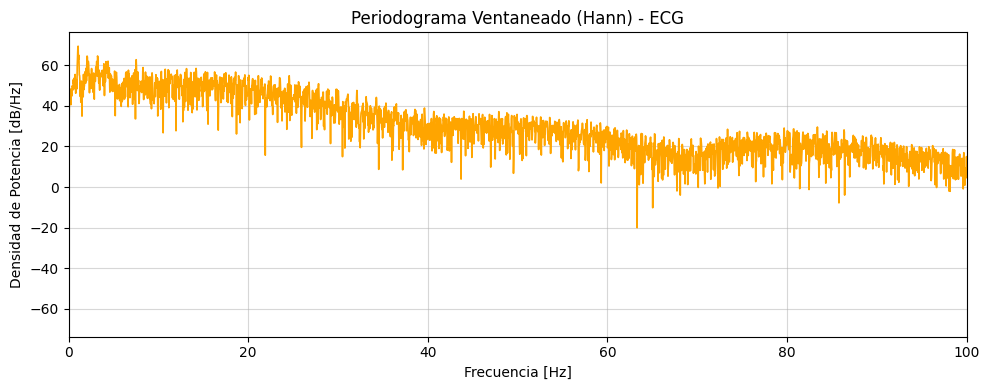

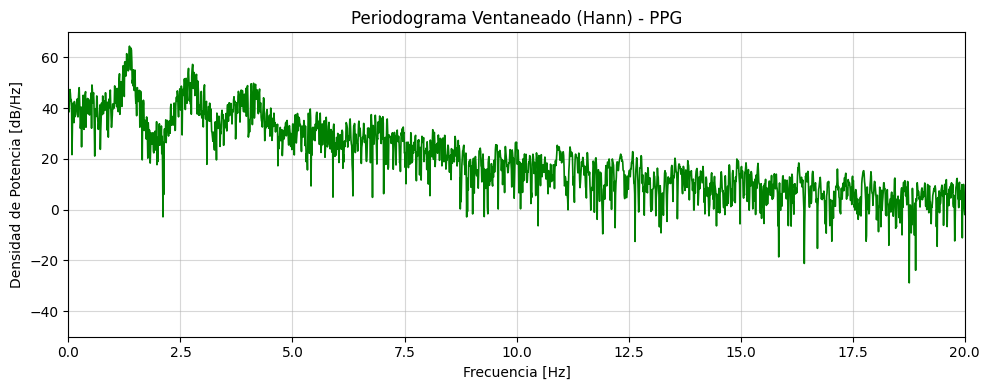

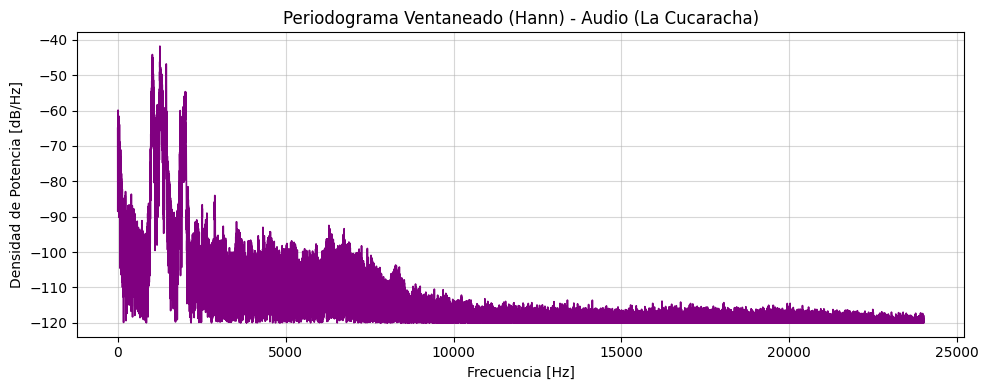

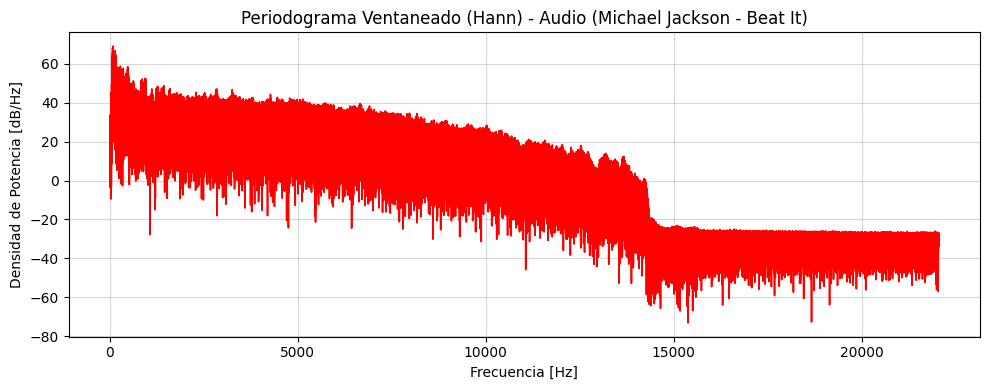

In [4]:
f_ecg, psd_ecg = signal.periodogram(ecg, fs=fs_ecg, window='hann')
f_ppg, psd_ppg = signal.periodogram(ppg, fs=fs_ppg, window='hann')
f_audio, psd_audio = signal.periodogram(audio, fs=fs_audio, window='hann')
f_mj, psd_mj = signal.periodogram(mj, fs=fs_mj, window='hann')

plt.figure(figsize=(10, 4))
plt.plot(f_ecg, 10 * np.log10(psd_ecg + 1e-12), color='orange', lw=1.2)
plt.title('Periodograma Ventaneado (Hann) - ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.xlim(0, 100)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(f_ppg, 10 * np.log10(psd_ppg + 1e-12), color='green', lw=1.2)
plt.title('Periodograma Ventaneado (Hann) - PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.xlim(0, 20)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(f_audio, 10 * np.log10(psd_audio + 1e-12), color='purple', lw=1.2)
plt.title('Periodograma Ventaneado (Hann) - Audio (La Cucaracha)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(f_mj, 10 * np.log10(psd_mj + 1e-12), color='red', lw=1.2)
plt.title('Periodograma Ventaneado (Hann) - Audio (Michael Jackson - Beat It)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Estimación Espectral: Método de Welch

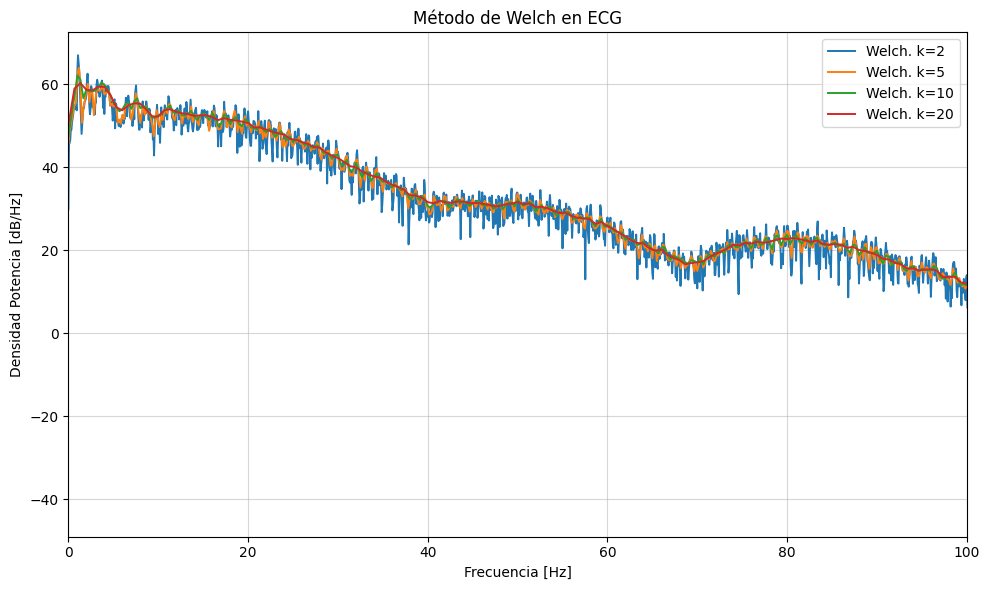

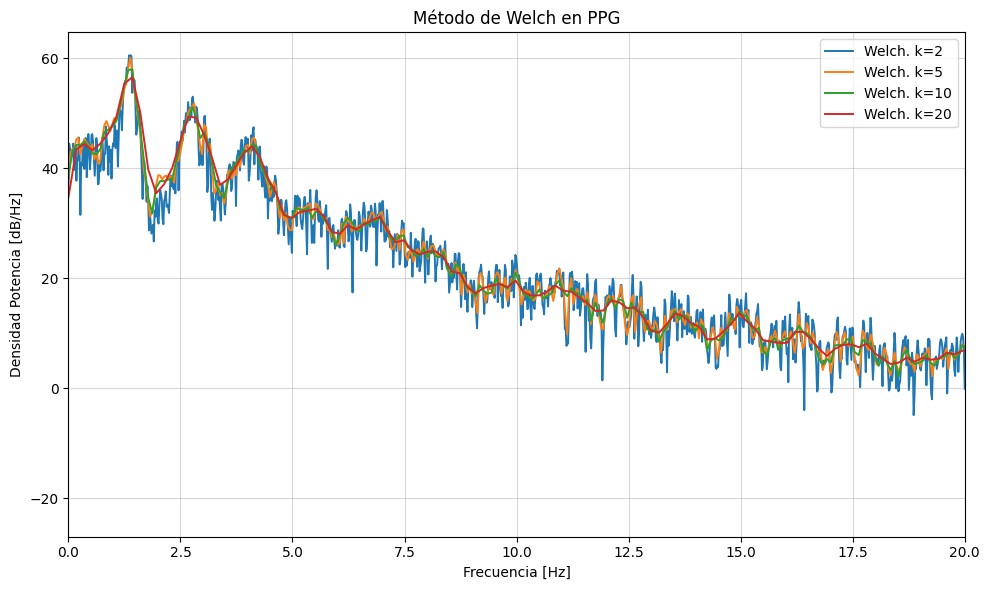

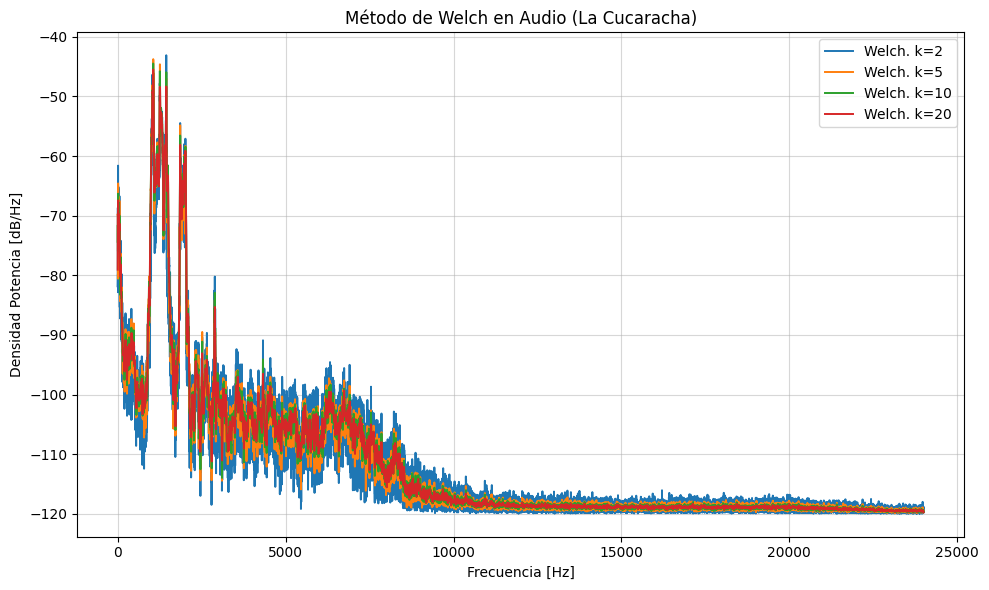

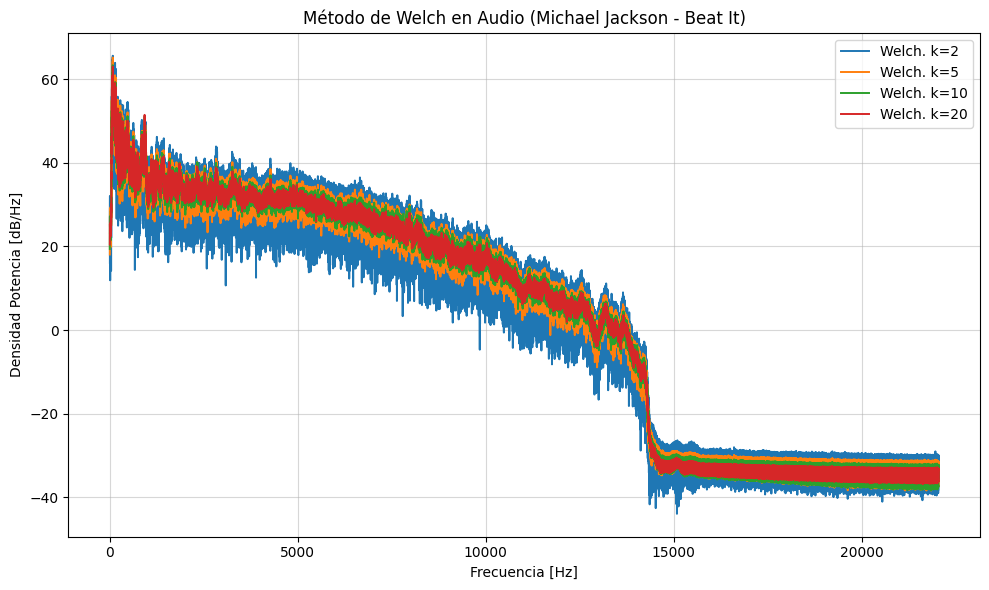

In [5]:
k_values = [2, 5, 10, 20]

# ECG
N_ecg = ecg.size
plt.figure(figsize=(10, 6))
for k in k_values:
    nperseg_ecg = int(N_ecg / k)
    f_ecg_w, psd_ecg_w = signal.welch(ecg, fs=fs_ecg, nperseg=nperseg_ecg)
    plt.plot(f_ecg_w, 10 * np.log10(psd_ecg_w + 1e-12), lw=1.4, label=f"Welch. k={k}")
plt.title('Método de Welch en ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB/Hz]')
plt.xlim(0, 100)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# PPG
N_ppg = ppg.size
plt.figure(figsize=(10, 6))
for k in k_values:
    nperseg_ppg = int(N_ppg / k)
    f_ppg_w, psd_ppg_w = signal.welch(ppg, fs=fs_ppg, nperseg=nperseg_ppg)
    plt.plot(f_ppg_w, 10 * np.log10(psd_ppg_w + 1e-12), lw=1.4, label=f"Welch. k={k}")
plt.title('Método de Welch en PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB/Hz]')
plt.xlim(0, 20)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Audio
N_audio = audio.size
plt.figure(figsize=(10, 6))
for k in k_values:
    nperseg_audio = int(N_audio / k)
    f_audio_w, psd_audio_w = signal.welch(audio, fs=fs_audio, nperseg=nperseg_audio)
    plt.plot(f_audio_w, 10 * np.log10(psd_audio_w + 1e-12), lw=1.4, label=f"Welch. k={k}")
plt.title('Método de Welch en Audio (La Cucaracha)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB/Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Michael Jackson
N_mj = mj.size
plt.figure(figsize=(10, 6))
for k in k_values:
    nperseg_mj = int(N_mj / k)
    f_mj_w, psd_mj_w = signal.welch(mj, fs=fs_mj, nperseg=nperseg_mj)
    plt.plot(f_mj_w, 10 * np.log10(psd_mj_w + 1e-12), lw=1.4, label=f"Welch. k={k}")
plt.title('Método de Welch en Audio (Michael Jackson - Beat It)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB/Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Estimación Espectral: Método de Blackman-Tukey

Se usa `M = N/div` para varios divisores: `div` grande → M chico → más suave; `div` chico → M grande → más resolución (y más varianza), análogo al compromiso de Welch con k.

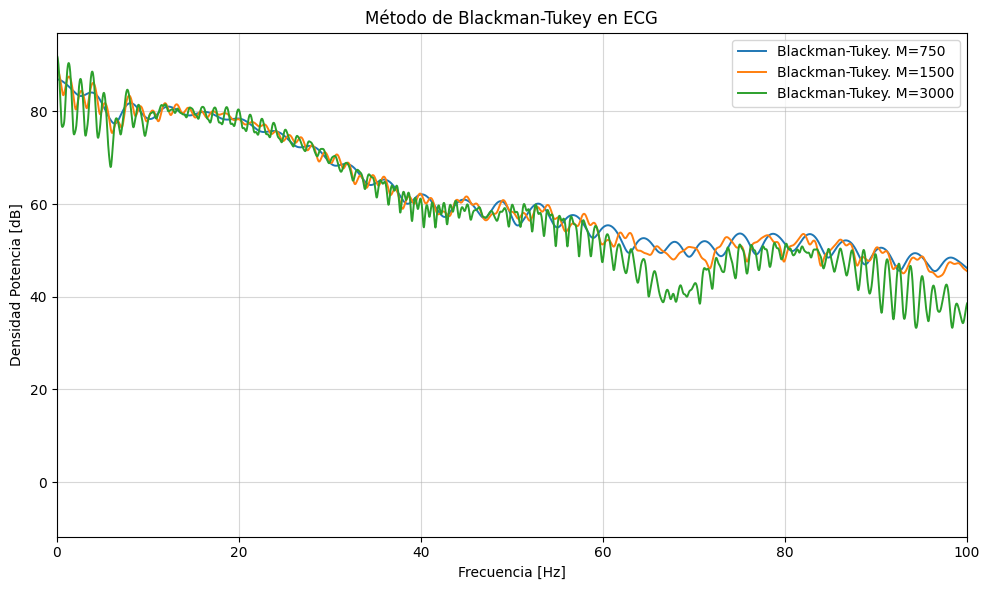

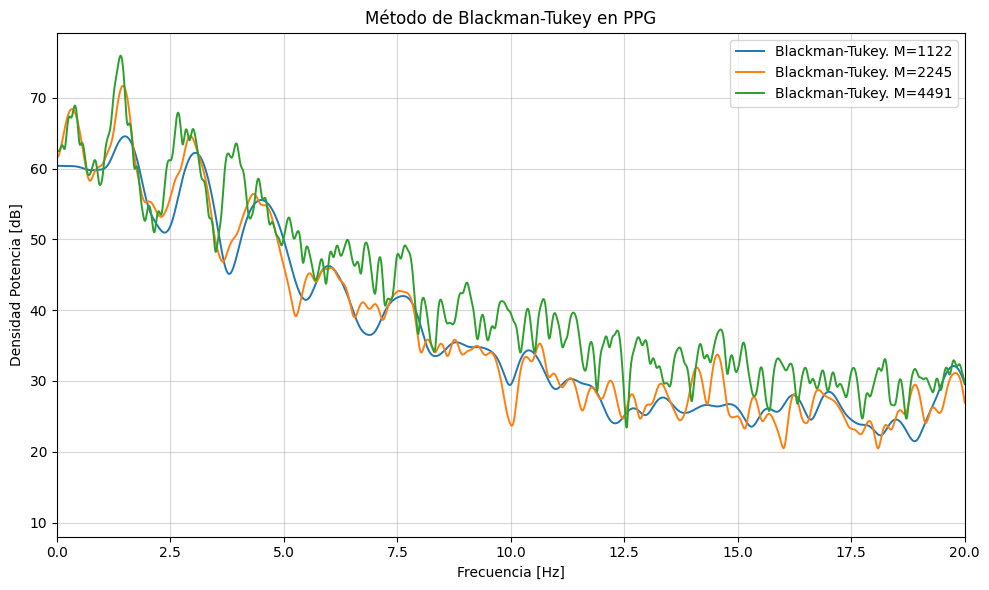

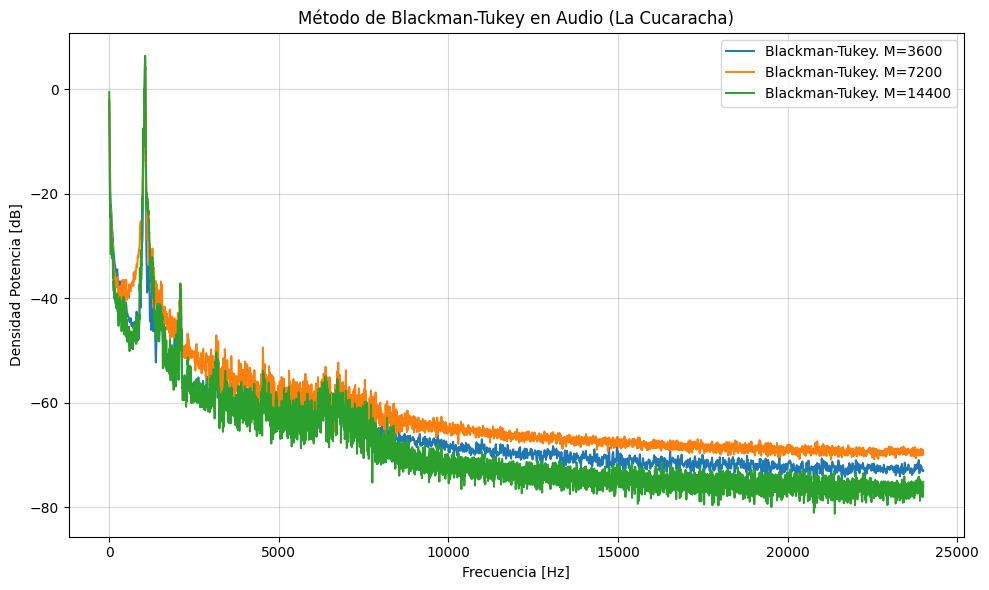

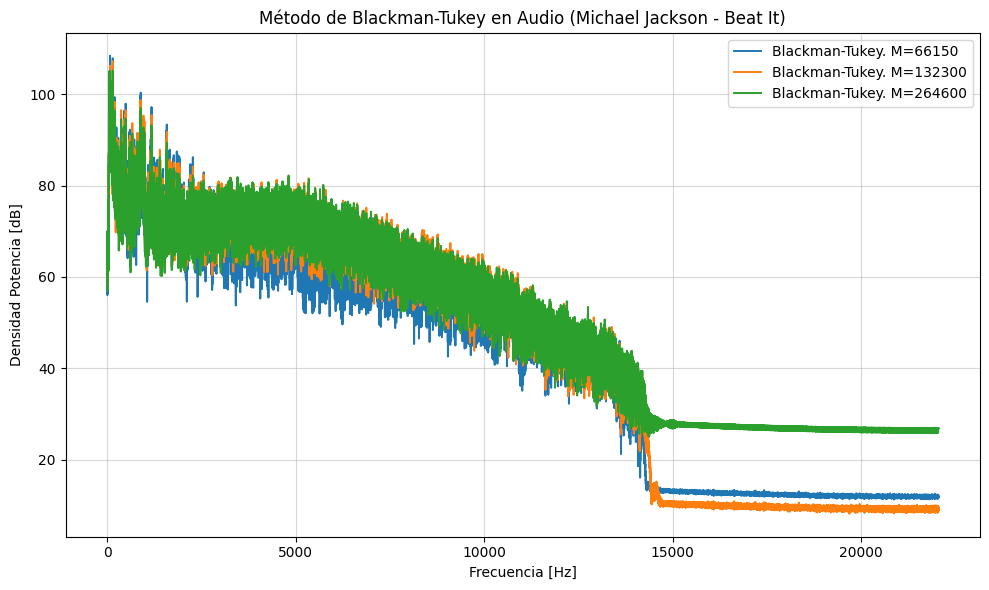

In [6]:
bt_divs = [40, 20, 10]

# ECG
ff_ecg_bt, bfrec_ecg = frecuencias(N_ecg, fs_ecg)
plt.figure(figsize=(10, 6))
for div in bt_divs:
    M = N_ecg // div
    Px = blackman_tukey(ecg, M)
    psd_db = 10 * np.log10(np.abs(Px[bfrec_ecg]) + 1e-12)
    plt.plot(ff_ecg_bt[bfrec_ecg], psd_db, lw=1.4, label=f"Blackman-Tukey. M={M}")
plt.title('Método de Blackman-Tukey en ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB]')
plt.xlim(0, 100)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# PPG
ff_ppg_bt, bfrec_ppg = frecuencias(N_ppg, fs_ppg)
plt.figure(figsize=(10, 6))
for div in bt_divs:
    M = N_ppg // div
    Px = blackman_tukey(ppg, M)
    psd_db = 10 * np.log10(np.abs(Px[bfrec_ppg]) + 1e-12)
    plt.plot(ff_ppg_bt[bfrec_ppg], psd_db, lw=1.4, label=f"Blackman-Tukey. M={M}")
plt.title('Método de Blackman-Tukey en PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB]')
plt.xlim(0, 20)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Audio
ff_audio_bt, bfrec_audio = frecuencias(N_audio, fs_audio)
plt.figure(figsize=(10, 6))
for div in bt_divs:
    M = N_audio // div
    Px = blackman_tukey(audio, M)
    psd_db = 10 * np.log10(np.abs(Px[bfrec_audio]) + 1e-12)
    plt.plot(ff_audio_bt[bfrec_audio], psd_db, lw=1.4, label=f"Blackman-Tukey. M={M}")
plt.title('Método de Blackman-Tukey en Audio (La Cucaracha)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Michael Jackson
ff_mj_bt, bfrec_mj = frecuencias(N_mj, fs_mj)
plt.figure(figsize=(10, 6))
for div in bt_divs:
    M = N_mj // div
    Px = blackman_tukey(mj, M)
    psd_db = 10 * np.log10(np.abs(Px[bfrec_mj]) + 1e-12)
    plt.plot(ff_mj_bt[bfrec_mj], psd_db, lw=1.4, label=f"Blackman-Tukey. M={M}")
plt.title('Método de Blackman-Tukey en Audio (Michael Jackson - Beat It)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Potencia [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Ancho de Banda: 95% de Energía Acumulada

In [7]:
def bw95(f, psd):
    c = np.cumsum(psd)
    return f[np.searchsorted(c, 0.95 * c[-1])]

print(f"\n{'Señal':<7}{'Periodog.':>11}{'Welch':>9}{'k':>5}{'Black-Tukey':>13}{'M':>8}   [Hz]")
for name, x, fs in [('ECG', ecg, fs_ecg), ('PPG', ppg, fs_ppg), ('Audio', audio, fs_audio), ('MJ', mj, fs_mj)]:
    N = x.size
    k = 10
    M = N // k
    fp, pp = signal.periodogram(x, fs=fs, window='hann')
    fw, pw = signal.welch(x, fs=fs, nperseg=N // k)
    ff, half = frecuencias(N, fs)
    pbt = np.abs(blackman_tukey(x, M)[half])
    print(f"{name:<7}{bw95(fp, pp):>11.2f}{bw95(fw, pw):>9.2f}{k:>5}{bw95(ff[half], pbt):>13.2f}{M:>8}")



Señal    Periodog.    Welch    k  Black-Tukey       M   [Hz]
ECG          23.57    22.67   10        24.30    3000
PPG           3.99     3.92   10         3.97    4491
Audio      1861.67  1486.67   10      1069.67   14400
MJ         4583.40  4713.67   10      5036.62  264600
